### Experimental Setup

In [25]:
FEATURE_SELECTION_METHOD = "FLAML"
DEEP_LEARNING_CATEGORY = "Attention"
MODEL_ARCHITECTURE = "Transformer"
DATASET_NAME = "Opensnoop"

**Developed By:** eDySec Research Team  
**Platform:** Ubuntu

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Python Version Checking

In [26]:
# ============================================================
# Python Environment Verification
# ============================================================

# Display the current Python version to ensure compatibility
# with the required libraries and experimental setup

!python --version

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Python 3.10.20


### GPU Checking

In [27]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Tue Mar 24 22:00:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   31C    P8             12W /  300W |     830MiB /  49140MiB |     12%      Default |
|           

### Install Necessary Packages

In [3]:
# ============================================================
# Dependency Installation
# ============================================================

# Install all required packages from requirements.txt
# --no-cache-dir ensures a clean installation without using cached packages

!pip install --no-cache-dir -r requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of scikit-image to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of ipykernel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 59.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 90.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 87.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 50.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 58.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.8/529.8 kB 67.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.9/532.9 kB 79.8 MB/s  0:00:00
   ━━━━━━━━━

### Import Necessary Packages

In [28]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import time
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
)
from scipy.sparse import hstack, csr_matrix

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================================
# Transformers
# ============================================================
from transformers import (
    BertTokenizer,
    TFBertModel,
    GPT2Tokenizer,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
from flaml import AutoML
import joblib

### GPU Status Checking

In [29]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [30]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    
    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")
    
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [31]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Total_Paths,Total_Error,Total_ File_Descriptor,Python_Related_Keywords,Install_Package_Keywords,Root_DIR_Installation,Temporary_DIR_Installation,Home_DIR_Installation,User_Access,Sys_Access,Etc_DIR_Installation,Other_DIR_Installation,Level
0,10Cent10-999.0.4.tar.gz,8045,8045,29,1083,2305,0,71,792,411,1225,151,5395,1
1,10Cent11-999.0.4.tar.gz,4790,4790,12,1616,843,2,87,1118,721,1200,104,1558,1
2,11Cent-999.0.0.tar.gz,26159,26159,27,3299,4536,0,200,2485,1072,1236,450,20716,1
3,11Cent-999.0.1.tar.gz,11194,11194,28,1521,2558,2,97,1035,891,1211,265,7693,1
4,11Cent-999.0.2.tar.gz,13561,13561,35,2656,5265,501,17,1497,1719,1219,291,8317,1


### Clear Backend Session

In [32]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Feature Processing

In [33]:
# ============================================================
# Metadata Preprocessing and Feature Construction (Numerical Only)
# ============================================================

# Remove non-informative identifier column if present
if 'Package_Name' in data.columns:
    data = data.drop(columns=['Package_Name'])

# ------------------------------------------------------------
# Step 1: Extract numerical features
# ------------------------------------------------------------

# Select numerical columns (excluding target label)
numerical_columns = [
    col for col in data.columns
    if pd.to_numeric(data[col], errors='coerce').notnull().all() and col != 'Level'
]

# Convert to float and handle missing values
X = data[numerical_columns].fillna(0).astype(float)

# ------------------------------------------------------------
# Step 2: Feature scaling
# ------------------------------------------------------------

# Standardize features (important for DL models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### AutoML Implementation

In [11]:
# Assume 'data' is your pandas DataFrame
X = data.drop(columns=['Level'])
y = data['Level']

if y.dtype == 'object' or y.dtype.name == 'category':
    y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize FLAML
automl = AutoML()
automl_settings = {
    "time_budget": 300,
    "metric": "accuracy",
    "task": "classification",
}

automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

# Feature importance & selection
selected_features = X.columns.tolist()
dropped_features = []

try:
    importances = automl.model.feature_importances_

    # Sometimes LGBM may drop unused features -> align with all columns
    if len(importances) < X.shape[1]:
        full_importances = np.zeros(X.shape[1])
        # Use feature names from model if available
        try:
            model_features = automl.model.booster_.feature_name()
            for i, col in enumerate(X.columns):
                if col in model_features:
                    idx = model_features.index(col)
                    full_importances[i] = importances[idx]
        except:
            full_importances[:len(importances)] = importances
        importances = full_importances

    varimp = pd.DataFrame({'variable': X.columns, 'importance': importances})
    varimp['relative_importance'] = varimp['importance'] / varimp['importance'].sum()

    threshold = 0.03
    selected_features = list(varimp[varimp['relative_importance'] > threshold]['variable'])
    dropped_features = list(varimp[varimp['relative_importance'] <= threshold]['variable'])

    print("Feature importance table:\n", varimp)

except AttributeError:
    print("Feature importance not available for the chosen model.")

print("\nSelected features:", selected_features)
print("Number of features kept:", len(selected_features))
print("\nDropped features:", dropped_features)
print("Number of features dropped:", len(dropped_features))

[flaml.automl.logger: 03-24 13:56:16] {2375} INFO - task = classification
[flaml.automl.logger: 03-24 13:56:16] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 03-24 13:56:16] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 03-24 13:56:16] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 03-24 13:56:16] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-24 13:56:17] {3046} INFO - Estimated sufficient time budget=7096s. Estimated necessary time budget=164s.
[flaml.automl.logger: 03-24 13:56:17] {3097} INFO -  at 0.7s,	estimator lgbm's best error=2.1321e-01,	best estimator lgbm's best error=2.1321e-01
[flaml.automl.logger: 03-24 13:56:17] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-24 13:56:17] {3097} INFO -  at 1.0s,	estimator lgbm's best error=2.1321e-01,	best estimator lgbm's best error=2.1321e-01
[flaml.aut

[flaml.automl.logger: 03-24 13:56:25] {2911} INFO - iteration 33, current learner lgbm
[flaml.automl.logger: 03-24 13:56:27] {3097} INFO -  at 10.5s,	estimator lgbm's best error=5.1682e-02,	best estimator lgbm's best error=5.1682e-02
[flaml.automl.logger: 03-24 13:56:27] {2911} INFO - iteration 34, current learner sgd
[flaml.automl.logger: 03-24 13:56:27] {3097} INFO -  at 10.7s,	estimator sgd's best error=2.9266e-01,	best estimator lgbm's best error=5.1682e-02
[flaml.automl.logger: 03-24 13:56:27] {2911} INFO - iteration 35, current learner lgbm
[flaml.automl.logger: 03-24 13:56:28] {3097} INFO -  at 11.6s,	estimator lgbm's best error=5.0630e-02,	best estimator lgbm's best error=5.0630e-02
[flaml.automl.logger: 03-24 13:56:28] {2911} INFO - iteration 36, current learner lgbm
[flaml.automl.logger: 03-24 13:56:28] {3097} INFO -  at 11.8s,	estimator lgbm's best error=5.0630e-02,	best estimator lgbm's best error=5.0630e-02
[flaml.automl.logger: 03-24 13:56:28] {2911} INFO - iteration 37, 

[flaml.automl.logger: 03-24 13:56:44] {2911} INFO - iteration 68, current learner xgboost
[flaml.automl.logger: 03-24 13:56:44] {3097} INFO -  at 28.0s,	estimator xgboost's best error=6.0529e-02,	best estimator lgbm's best error=5.0630e-02
[flaml.automl.logger: 03-24 13:56:44] {2911} INFO - iteration 69, current learner lgbm
[flaml.automl.logger: 03-24 13:56:45] {3097} INFO -  at 28.6s,	estimator lgbm's best error=5.0630e-02,	best estimator lgbm's best error=5.0630e-02
[flaml.automl.logger: 03-24 13:56:45] {2911} INFO - iteration 70, current learner xgboost
[flaml.automl.logger: 03-24 13:56:45] {3097} INFO -  at 28.8s,	estimator xgboost's best error=6.0529e-02,	best estimator lgbm's best error=5.0630e-02
[flaml.automl.logger: 03-24 13:56:45] {2911} INFO - iteration 71, current learner xgboost
[flaml.automl.logger: 03-24 13:56:47] {3097} INFO -  at 30.5s,	estimator xgboost's best error=5.5273e-02,	best estimator lgbm's best error=5.0630e-02
[flaml.automl.logger: 03-24 13:56:47] {2911} I

[flaml.automl.logger: 03-24 13:57:08] {2911} INFO - iteration 103, current learner lgbm
[flaml.automl.logger: 03-24 13:57:10] {3097} INFO -  at 53.8s,	estimator lgbm's best error=4.8703e-02,	best estimator lgbm's best error=4.8703e-02
[flaml.automl.logger: 03-24 13:57:10] {2911} INFO - iteration 104, current learner extra_tree
[flaml.automl.logger: 03-24 13:57:10] {3097} INFO -  at 54.0s,	estimator extra_tree's best error=1.1659e-01,	best estimator lgbm's best error=4.8703e-02
[flaml.automl.logger: 03-24 13:57:10] {2911} INFO - iteration 105, current learner extra_tree
[flaml.automl.logger: 03-24 13:57:10] {3097} INFO -  at 54.3s,	estimator extra_tree's best error=1.1659e-01,	best estimator lgbm's best error=4.8703e-02
[flaml.automl.logger: 03-24 13:57:10] {2911} INFO - iteration 106, current learner extra_tree
[flaml.automl.logger: 03-24 13:57:11] {3097} INFO -  at 54.5s,	estimator extra_tree's best error=1.1659e-01,	best estimator lgbm's best error=4.8703e-02
[flaml.automl.logger: 03

### Selected Features

In [34]:
selected_features = ['Total_Paths', 'Total_Error', 'Total_ File_Descriptor', 'Python_Related_Keywords', 'Install_Package_Keywords', 'Root_DIR_Installation', 'Temporary_DIR_Installation', 'Home_DIR_Installation', 'User_Access', 'Sys_Access', 'Etc_DIR_Installation']

### Data Preprocessing

In [35]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 11)
Validation set shape   : (2141, 11)
Test set shape         : (2141, 11)


### Setup OUTPUT_DIR

In [36]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_Opensnoop_FLAML_Attention_Transformer'

### Model

In [37]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# ============================================================
# Convert each row into a single text string
# ============================================================
def row_to_text(df):
    texts = []
    for _, row in df.iterrows():
        parts = []
        for col in df.columns:
            value = row[col]
            parts.append(f"{col}: {value}")
        texts.append(" [SEP] ".join(parts))
    return texts


train_texts = row_to_text(X_train)
val_texts   = row_to_text(X_val)
test_texts  = row_to_text(X_test)


# ============================================================
# Tokenization
# ============================================================
max_words = 20000
max_len = 256

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_val_seq   = tokenizer.texts_to_sequences(val_texts)
X_test_seq  = tokenizer.texts_to_sequences(test_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")


# ============================================================
# Labels
# ============================================================
y_train = np.asarray(y_train).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)
y_test  = np.asarray(y_test).astype(np.float32)


# ============================================================
# Callbacks
# ============================================================
checkpoint_cb = ModelCheckpoint(
    MODEL_NAME,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=200,
    restore_best_weights=True,
    verbose=1
)


# ============================================================
# Transformer block
# ============================================================
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.2, l2_reg=1e-4):
        super().__init__()
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=rate
        )
        self.ffn = models.Sequential([
            layers.Dense(
                ff_dim,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_reg)
            ),
            layers.Dropout(rate),
            layers.Dense(
                embed_dim,
                kernel_regularizer=regularizers.l2(l2_reg)
            )
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


# ============================================================
# Token + Position Embedding
# ============================================================
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions


# ============================================================
# Build Transformer text classifier
# ============================================================
vocab_size = min(max_words, len(tokenizer.word_index) + 1)
embed_dim = 128
num_heads = 4
ff_dim = 256
num_blocks = 2
dropout_rate = 0.2
l2_reg = 1e-4

inputs = layers.Input(shape=(max_len,), dtype="int32")

x = TokenAndPositionEmbedding(max_len, vocab_size, embed_dim)(inputs)

for _ in range(num_blocks):
    x = TransformerBlock(
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim,
        rate=dropout_rate,
        l2_reg=l2_reg
    )(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs=inputs, outputs=outputs)


# ============================================================
# Compile model
# ============================================================
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256)]             0         
                                                                 
 token_and_position_embeddin  (None, 256, 128)         2048000   
 g (TokenAndPositionEmbeddin                                     
 g)                                                              
                                                                 
 transformer_block (Transfor  (None, 256, 128)         132480    
 merBlock)                                                       
                                                                 
 transformer_block_1 (Transf  (None, 256, 128)         132480    
 ormerBlock)                                                     
                                                                 
 global_average_pooling1d (G  (None, 128)              0     

### Compime the Model

In [40]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb],
    verbose=1
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
625/625 [==============================] - ETA: 0s - loss: 0.0781 - accuracy: 0.9849
Epoch 1: val_accuracy did not improve from 0.75199
625/625 [==============================] - 8s 13ms/step - loss: 0.0781 - accuracy: 0.9849 - val_loss: 0.9685 - val_accuracy: 0.7384 - lr: 3.0000e-04
Epoch 2/200
621/625 [============================>.] - ETA: 0s - loss: 0.0525 - accuracy: 0.9917
Epoch 2: val_accuracy did not improve from 0.75199
625/625 [==============================] - 8s 12ms/step - loss: 0.0524 - accuracy: 0.9918 - val_loss: 1.0012 - val_accuracy: 0.7473 - lr: 3.0000e-04
Epoch 3/200
623/625 [============================>.] - ETA: 0s - loss: 0.0373 - accuracy: 0.9958
Epoch 3: val_accuracy improved from 0.75199 to 0.75525, saving model to Evaluation_Outputs_Opensnoop_FLAML_Attention_Transformer/Evaluation_Outputs_Opensnoop_FLAML_Attention_Transformer.h5
625/625 [==============================] - 8s 13ms/step - loss: 0.0373 - accuracy: 0.9958 - val_loss: 1.3261 - val_accur

623/625 [============================>.] - ETA: 0s - loss: 0.0020 - accuracy: 0.9999
Epoch 27: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 0.0020 - accuracy: 0.9999 - val_loss: 2.0078 - val_accuracy: 0.7515 - lr: 3.0000e-04
Epoch 28/200
622/625 [============================>.] - ETA: 0s - loss: 0.0016 - accuracy: 0.9999
Epoch 28: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 0.0016 - accuracy: 0.9999 - val_loss: 2.0362 - val_accuracy: 0.7520 - lr: 3.0000e-04
Epoch 29/200
623/625 [============================>.] - ETA: 0s - loss: 0.0013 - accuracy: 0.9999
Epoch 29: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 0.0013 - accuracy: 0.9999 - val_loss: 2.0479 - val_accuracy: 0.7520 - lr: 3.0000e-04
Epoch 30/200
624/625 [============================>.] - ETA: 0s - loss: 9.8857e-04 - accuracy: 0.9999
Epoch 30: val_

624/625 [============================>.] - ETA: 0s - loss: 4.3084e-04 - accuracy: 0.9999
Epoch 54: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 4.3075e-04 - accuracy: 0.9999 - val_loss: 2.7020 - val_accuracy: 0.6833 - lr: 3.0000e-04
Epoch 55/200
623/625 [============================>.] - ETA: 0s - loss: 0.0020 - accuracy: 0.9995
Epoch 55: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 0.0020 - accuracy: 0.9995 - val_loss: 2.3942 - val_accuracy: 0.6716 - lr: 3.0000e-04
Epoch 56/200
623/625 [============================>.] - ETA: 0s - loss: 0.0010 - accuracy: 0.9998
Epoch 56: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 13ms/step - loss: 0.0010 - accuracy: 0.9998 - val_loss: 2.2490 - val_accuracy: 0.6969 - lr: 3.0000e-04
Epoch 57/200
624/625 [============================>.] - ETA: 0s - loss: 0.0017 - accuracy: 0.9996
Epoch 57: 

Epoch 81/200
625/625 [==============================] - ETA: 0s - loss: 6.1619e-04 - accuracy: 0.9999
Epoch 81: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 6.1619e-04 - accuracy: 0.9999 - val_loss: 2.1430 - val_accuracy: 0.7361 - lr: 3.0000e-04
Epoch 82/200
623/625 [============================>.] - ETA: 0s - loss: 5.2257e-04 - accuracy: 0.9999
Epoch 82: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 5.2188e-04 - accuracy: 0.9999 - val_loss: 2.0022 - val_accuracy: 0.7366 - lr: 3.0000e-04
Epoch 83/200
623/625 [============================>.] - ETA: 0s - loss: 5.0152e-04 - accuracy: 0.9999
Epoch 83: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 5.0086e-04 - accuracy: 0.9999 - val_loss: 1.9861 - val_accuracy: 0.7356 - lr: 3.0000e-04
Epoch 84/200
621/625 [============================>.] - ETA: 0s - loss: 4.6309e

Epoch 108/200
624/625 [============================>.] - ETA: 0s - loss: 6.9361e-04 - accuracy: 0.9997
Epoch 108: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 13ms/step - loss: 6.9340e-04 - accuracy: 0.9997 - val_loss: 1.6443 - val_accuracy: 0.6296 - lr: 3.0000e-04
Epoch 109/200
621/625 [============================>.] - ETA: 0s - loss: 5.9733e-04 - accuracy: 0.9999
Epoch 109: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 13ms/step - loss: 5.9545e-04 - accuracy: 0.9999 - val_loss: 1.7631 - val_accuracy: 0.7160 - lr: 3.0000e-04
Epoch 110/200
624/625 [============================>.] - ETA: 0s - loss: 6.1248e-04 - accuracy: 0.9999
Epoch 110: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 13ms/step - loss: 6.1227e-04 - accuracy: 0.9999 - val_loss: 1.7787 - val_accuracy: 0.7099 - lr: 3.0000e-04
Epoch 111/200
624/625 [============================>.] - ETA: 0s - loss: 

Epoch 135/200
621/625 [============================>.] - ETA: 0s - loss: 3.2999e-04 - accuracy: 0.9999
Epoch 135: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 13ms/step - loss: 3.2884e-04 - accuracy: 0.9999 - val_loss: 2.2234 - val_accuracy: 0.6894 - lr: 3.0000e-04
Epoch 136/200
621/625 [============================>.] - ETA: 0s - loss: 3.8084e-04 - accuracy: 0.9999
Epoch 136: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 3.7970e-04 - accuracy: 0.9999 - val_loss: 2.7675 - val_accuracy: 0.6039 - lr: 3.0000e-04
Epoch 137/200
621/625 [============================>.] - ETA: 0s - loss: 0.0045 - accuracy: 0.9992
Epoch 137: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 0.0044 - accuracy: 0.9992 - val_loss: 2.0987 - val_accuracy: 0.7212 - lr: 3.0000e-04
Epoch 138/200
625/625 [==============================] - ETA: 0s - loss: 8.0000e-

Epoch 162/200
625/625 [==============================] - ETA: 0s - loss: 5.0570e-04 - accuracy: 0.9999
Epoch 162: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 13ms/step - loss: 5.0570e-04 - accuracy: 0.9999 - val_loss: 1.9586 - val_accuracy: 0.6880 - lr: 3.0000e-04
Epoch 163/200
622/625 [============================>.] - ETA: 0s - loss: 3.9917e-04 - accuracy: 0.9999
Epoch 163: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 13ms/step - loss: 3.9829e-04 - accuracy: 0.9999 - val_loss: 1.8476 - val_accuracy: 0.6665 - lr: 3.0000e-04
Epoch 164/200
621/625 [============================>.] - ETA: 0s - loss: 4.5037e-04 - accuracy: 0.9999
Epoch 164: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 13ms/step - loss: 4.4882e-04 - accuracy: 0.9999 - val_loss: 1.8497 - val_accuracy: 0.6688 - lr: 3.0000e-04
Epoch 165/200
622/625 [============================>.] - ETA: 0s - loss: 

Epoch 189/200
621/625 [============================>.] - ETA: 0s - loss: 3.4019e-04 - accuracy: 0.9999
Epoch 189: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 13ms/step - loss: 3.3894e-04 - accuracy: 0.9999 - val_loss: 1.8087 - val_accuracy: 0.6698 - lr: 3.0000e-04
Epoch 190/200
624/625 [============================>.] - ETA: 0s - loss: 6.0717e-04 - accuracy: 0.9999
Epoch 190: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 6.0692e-04 - accuracy: 0.9999 - val_loss: 3.0649 - val_accuracy: 0.6128 - lr: 3.0000e-04
Epoch 191/200
624/625 [============================>.] - ETA: 0s - loss: 6.7234e-04 - accuracy: 0.9998
Epoch 191: val_accuracy did not improve from 0.75993
625/625 [==============================] - 8s 12ms/step - loss: 6.7207e-04 - accuracy: 0.9998 - val_loss: 2.0244 - val_accuracy: 0.6249 - lr: 3.0000e-04
Epoch 192/200
621/625 [============================>.] - ETA: 0s - loss: 

### Clear Backend Session

In [41]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [42]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()
val_loss, val_acc = model.evaluate(X_val_pad, y_val, verbose=0)
end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Time: 1559.83 seconds
Validation Time: 0.76 seconds
Testing Time: 0.40 seconds

Validation Accuracy: 0.7310
Test Accuracy: 0.7314


### Save Training Log

In [43]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_Opensnoop_FLAML_Attention_Transformer/training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.078078,0.984883,0.968530,0.738440,0.0003
1,2,0.052417,0.991791,1.001216,0.747314,0.0003
2,3,0.037267,0.995795,1.326073,0.755255,0.0003
3,4,0.031465,0.996696,1.706910,0.693134,0.0003
4,5,0.027389,0.997998,1.783000,0.740775,0.0003


### Trainig and Validation Plot

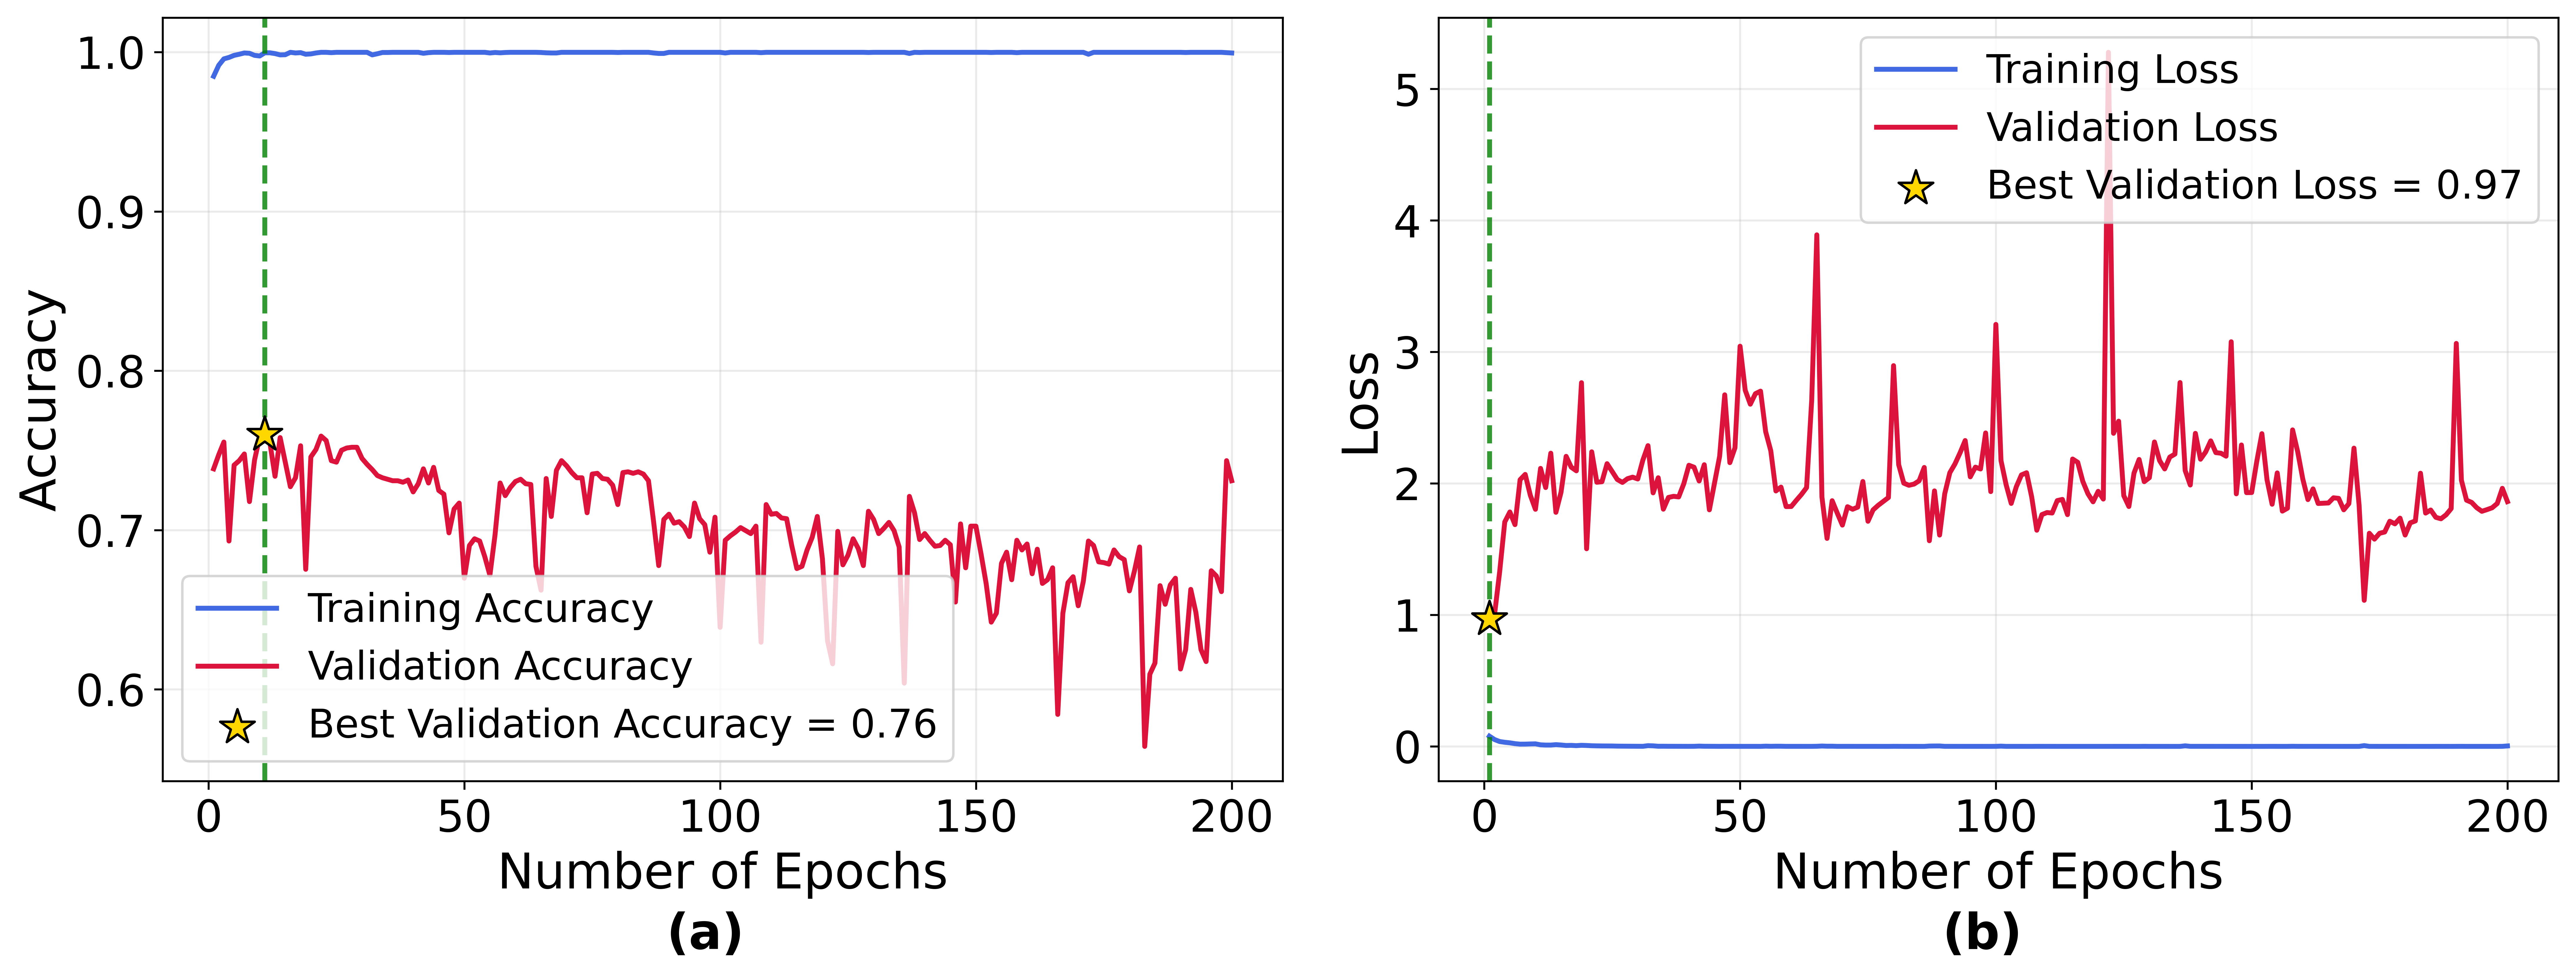

In [44]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report


Evaluation Results: Train
Accuracy  : 0.999900
Precision : 1.000000
Recall    : 0.999800
F1-score  : 0.999900
ROC AUC   : 1.000000
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.999800  1.000000  0.999900      5000
         1.0   1.000000  0.999800  0.999900      4989

    accuracy                       0.999900      9989
   macro avg   0.999900  0.999900  0.999900      9989
weighted avg   0.999900  0.999900  0.999900      9989



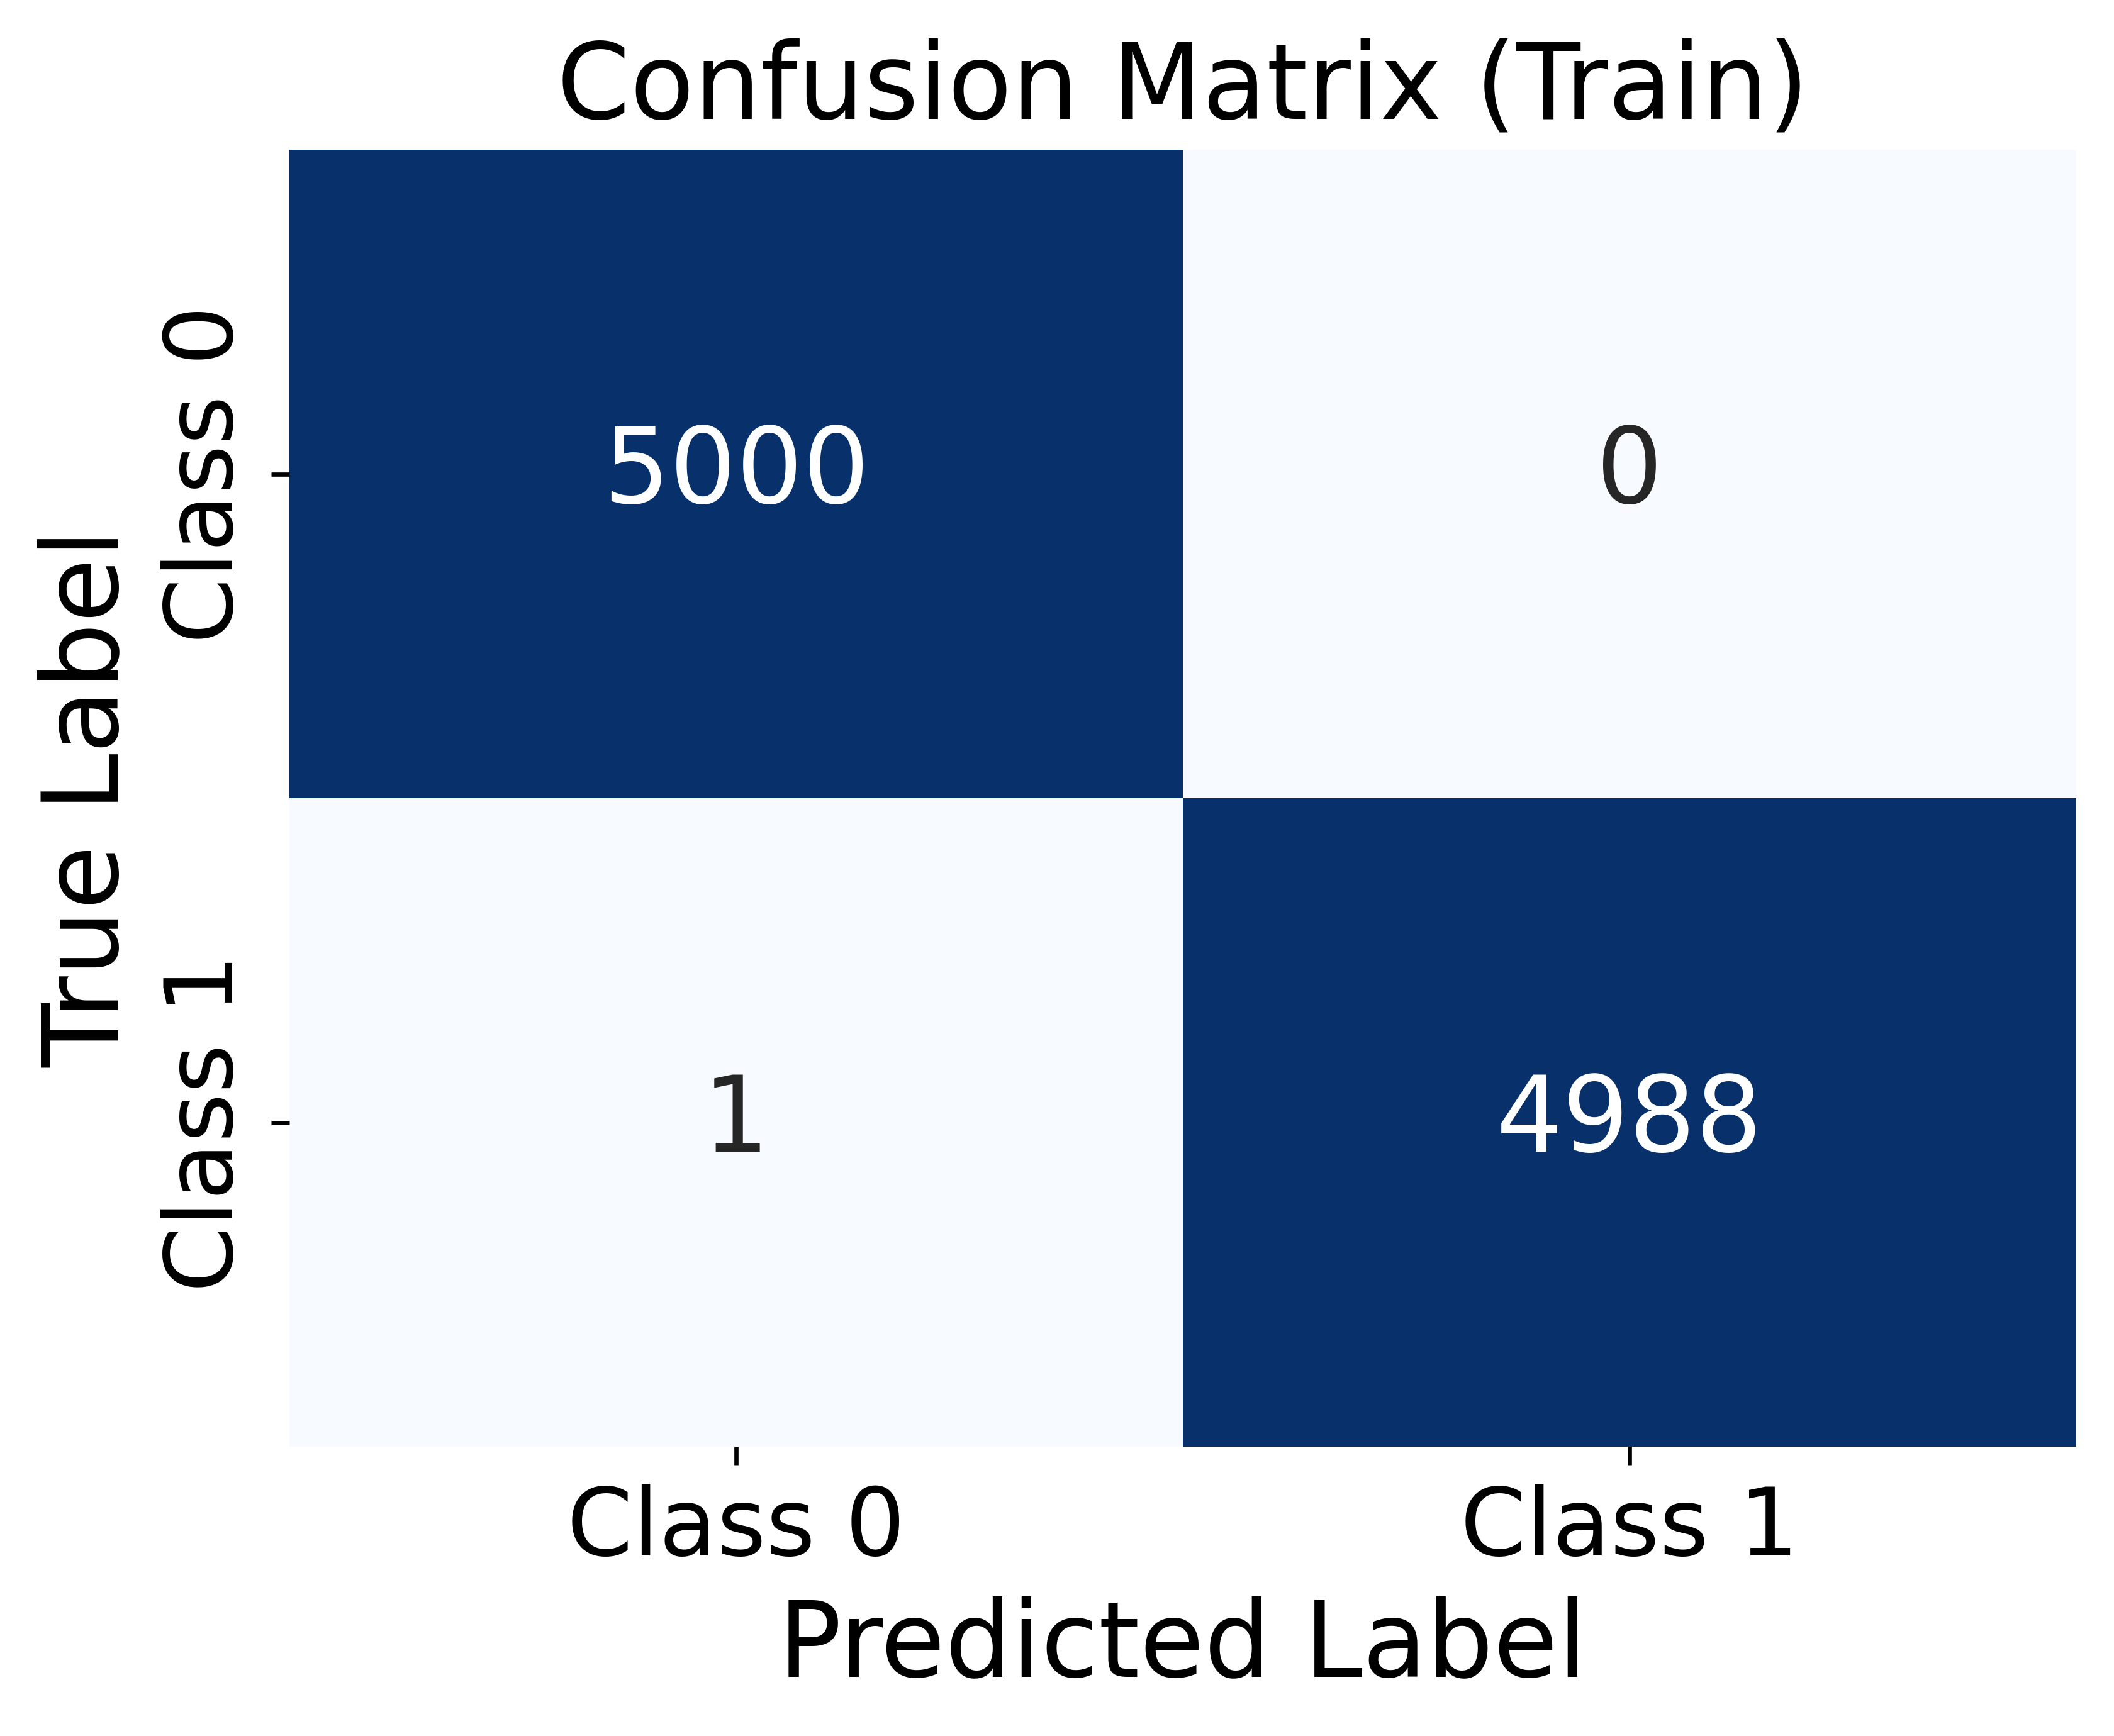

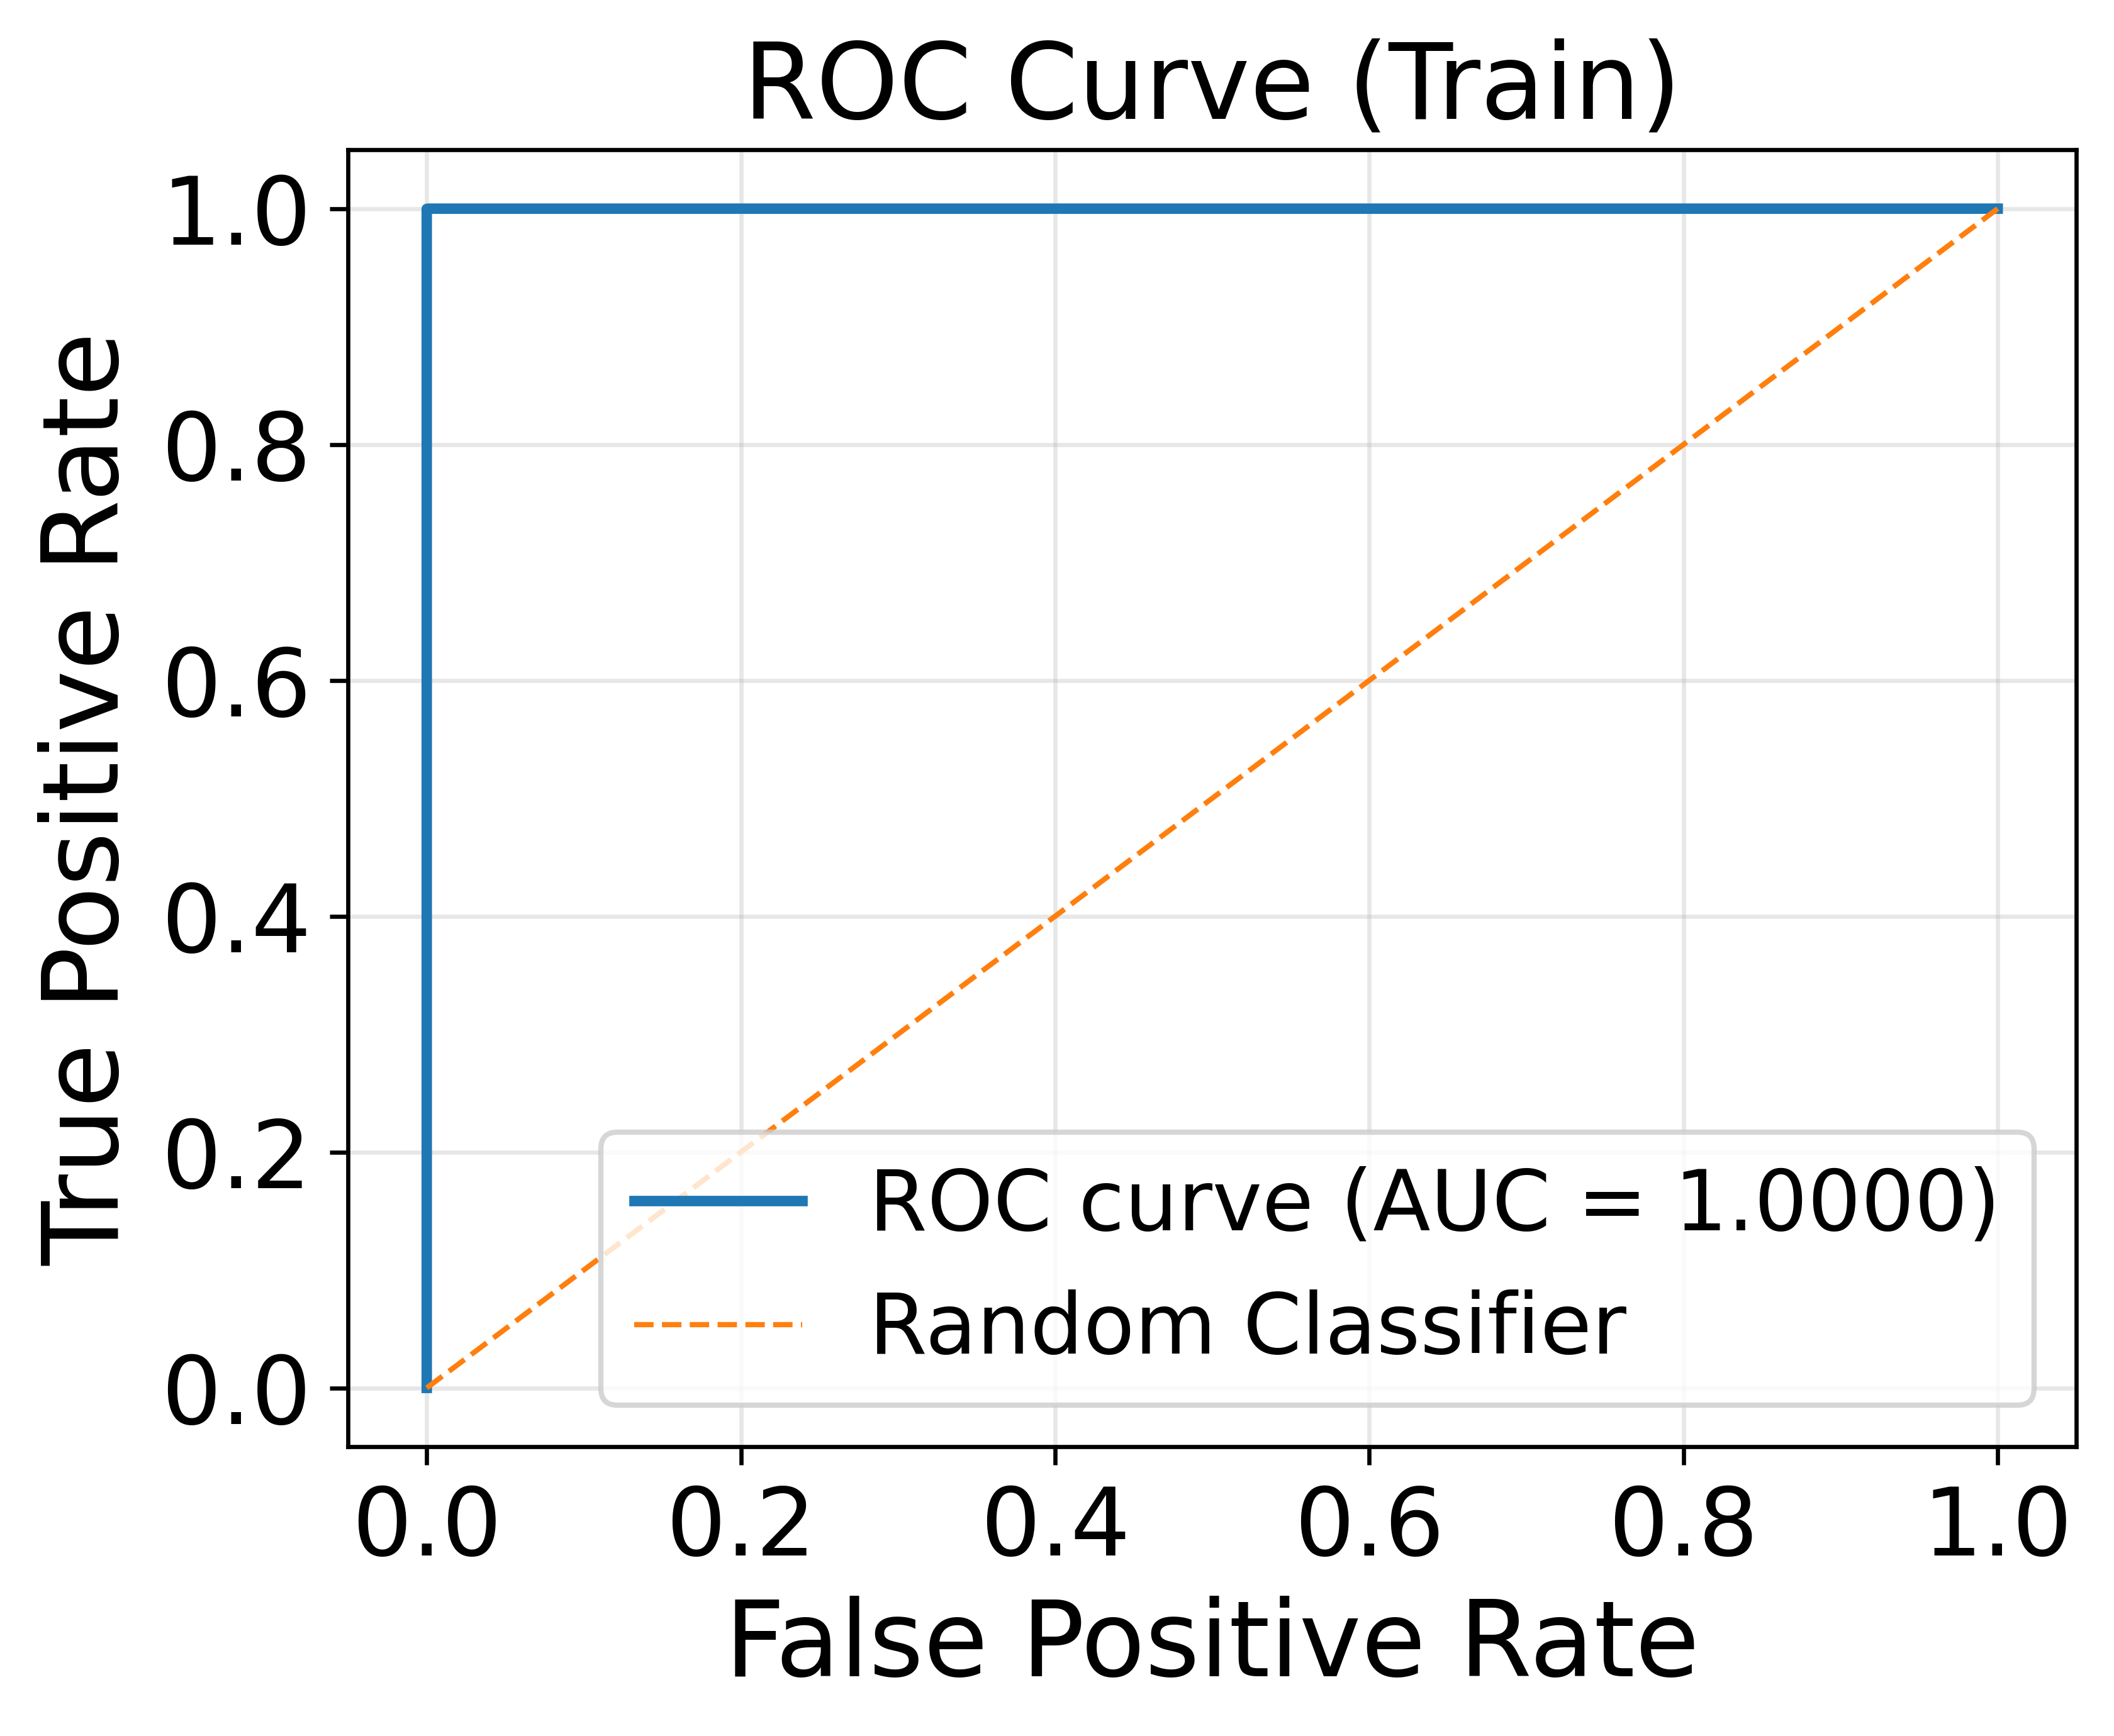


Evaluation Results: Validation
Accuracy  : 0.730967
Precision : 0.705246
Recall    : 0.792329
F1-score  : 0.746256
ROC AUC   : 0.787340
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.763830  0.669776  0.713718      1072
         1.0   0.705246  0.792329  0.746256      1069

    accuracy                       0.730967      2141
   macro avg   0.734538  0.731053  0.729987      2141
weighted avg   0.734579  0.730967  0.729964      2141



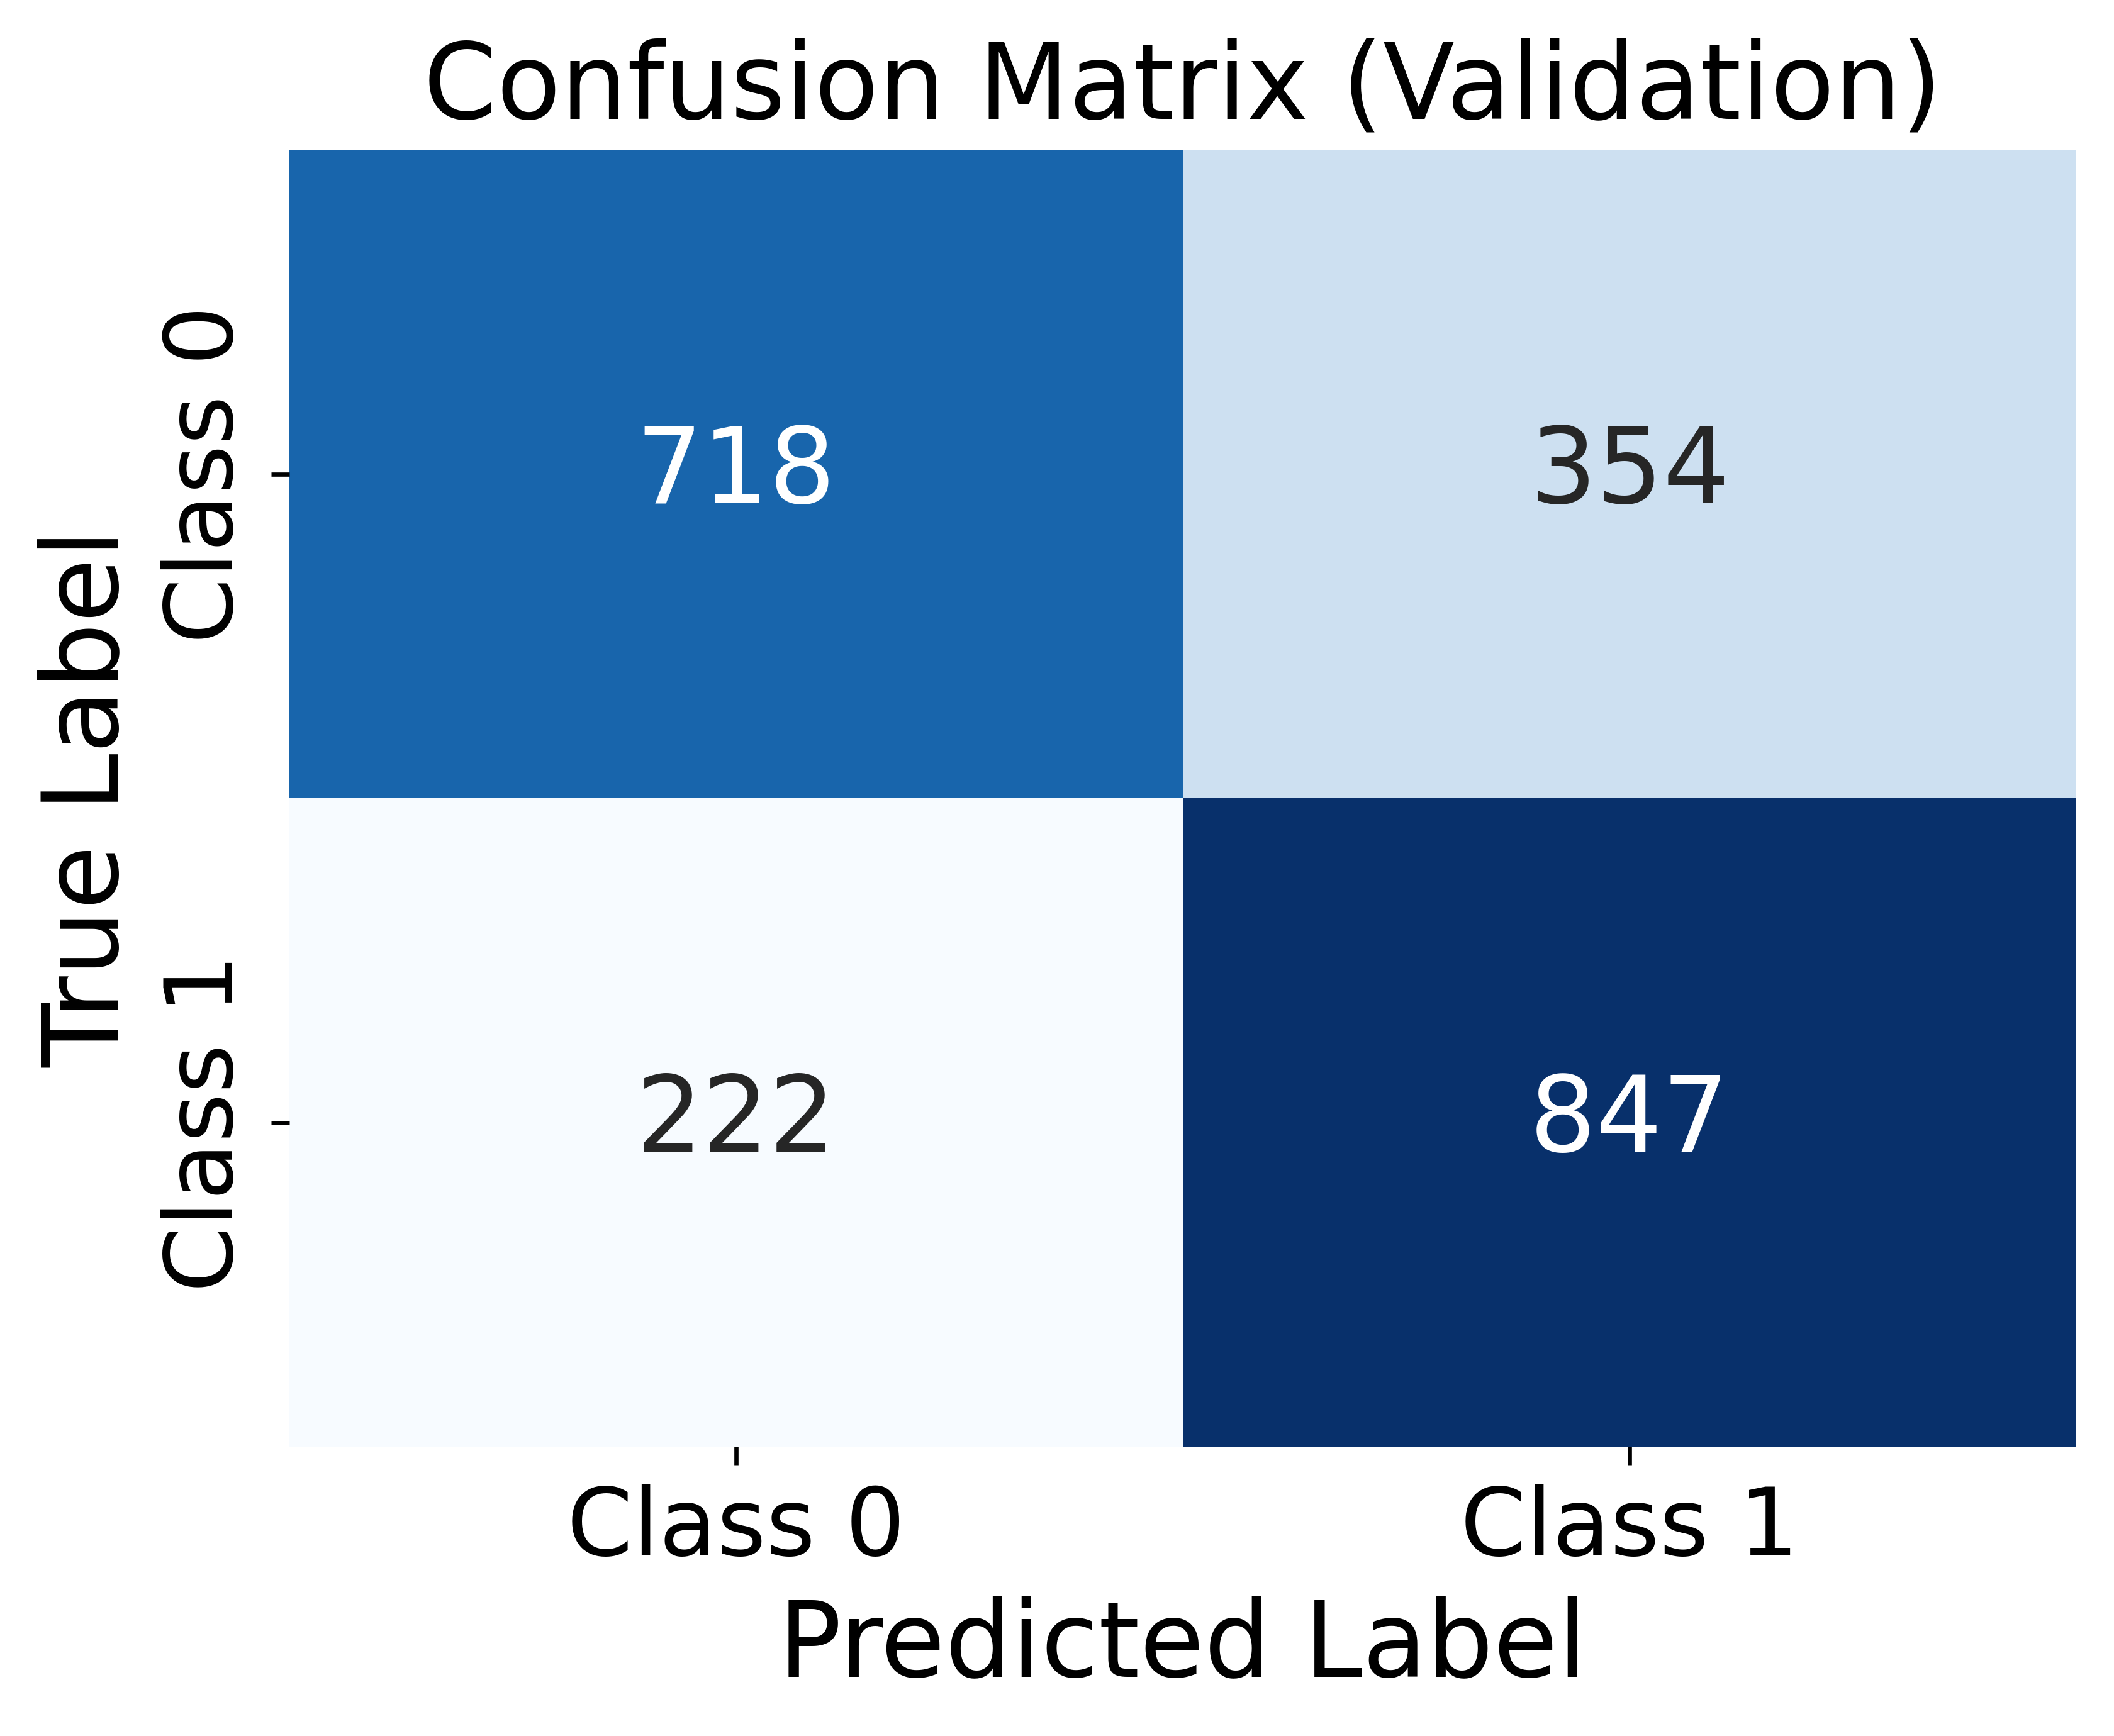

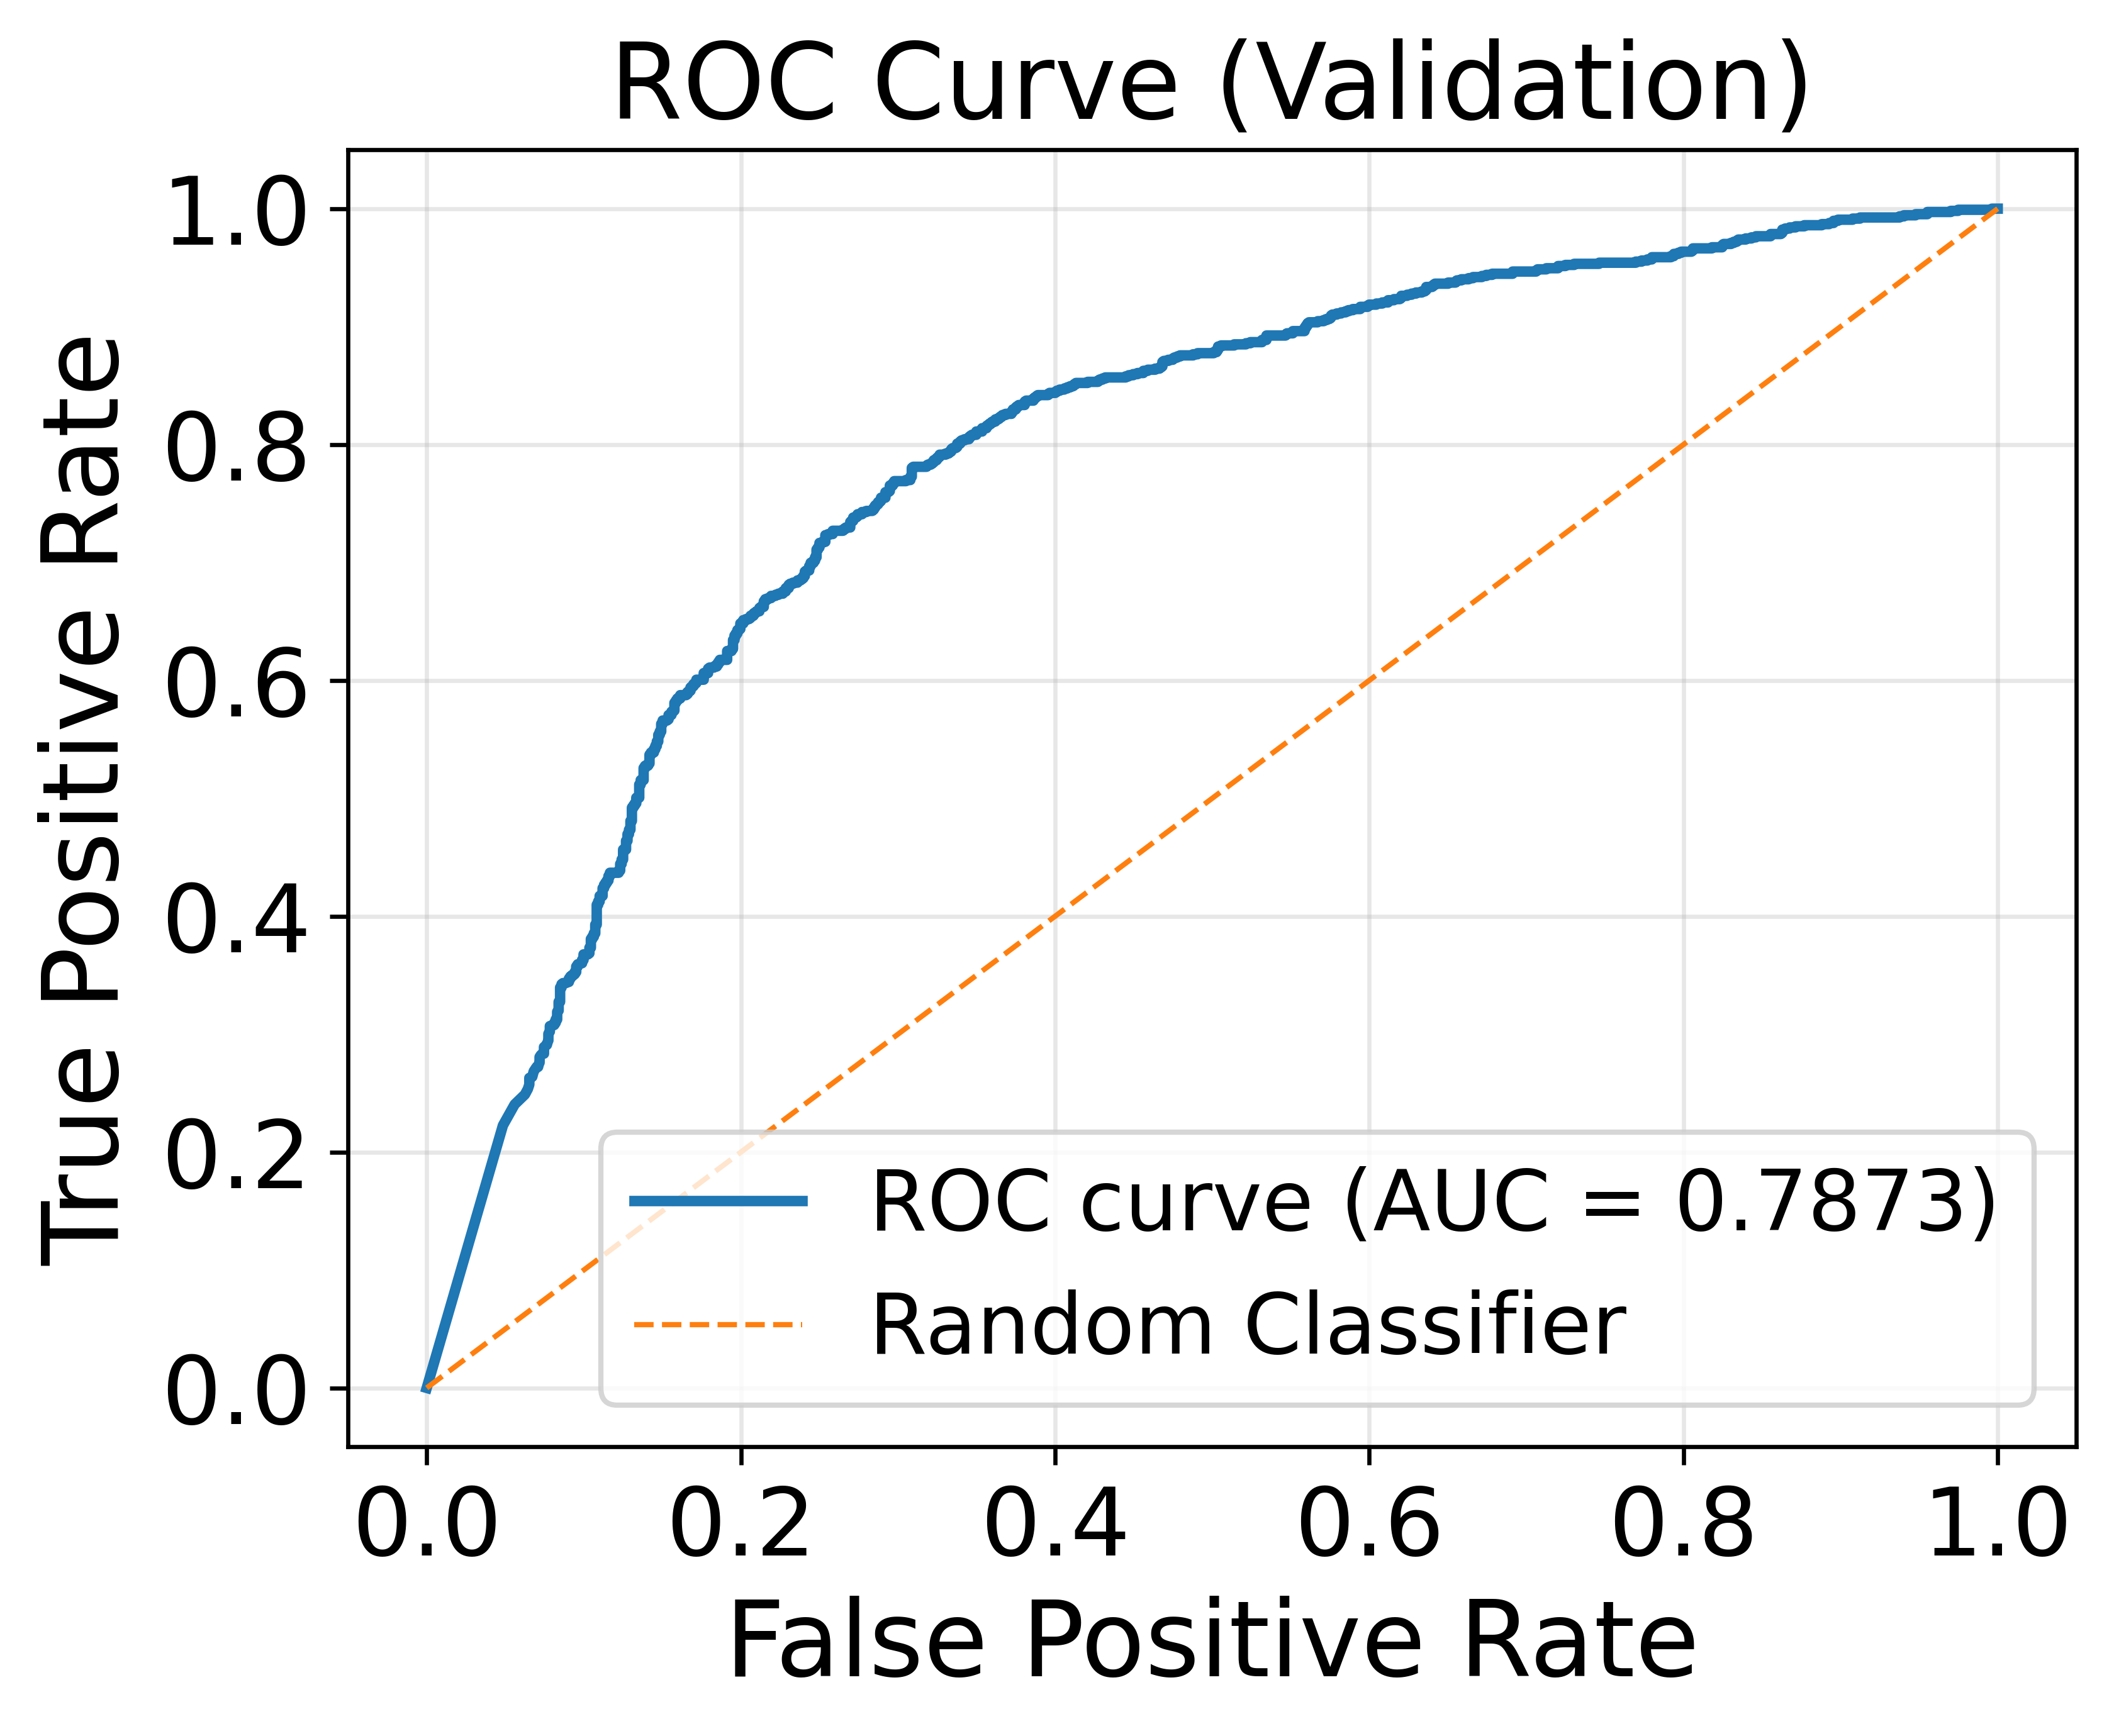


Evaluation Results: Test
Accuracy  : 0.731434
Precision : 0.704470
Recall    : 0.796071
F1-score  : 0.747475
ROC AUC   : 0.782238
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.766345  0.666978  0.713217      1072
         1.0   0.704470  0.796071  0.747475      1069

    accuracy                       0.731434      2141
   macro avg   0.735408  0.731524  0.730346      2141
weighted avg   0.735451  0.731434  0.730322      2141



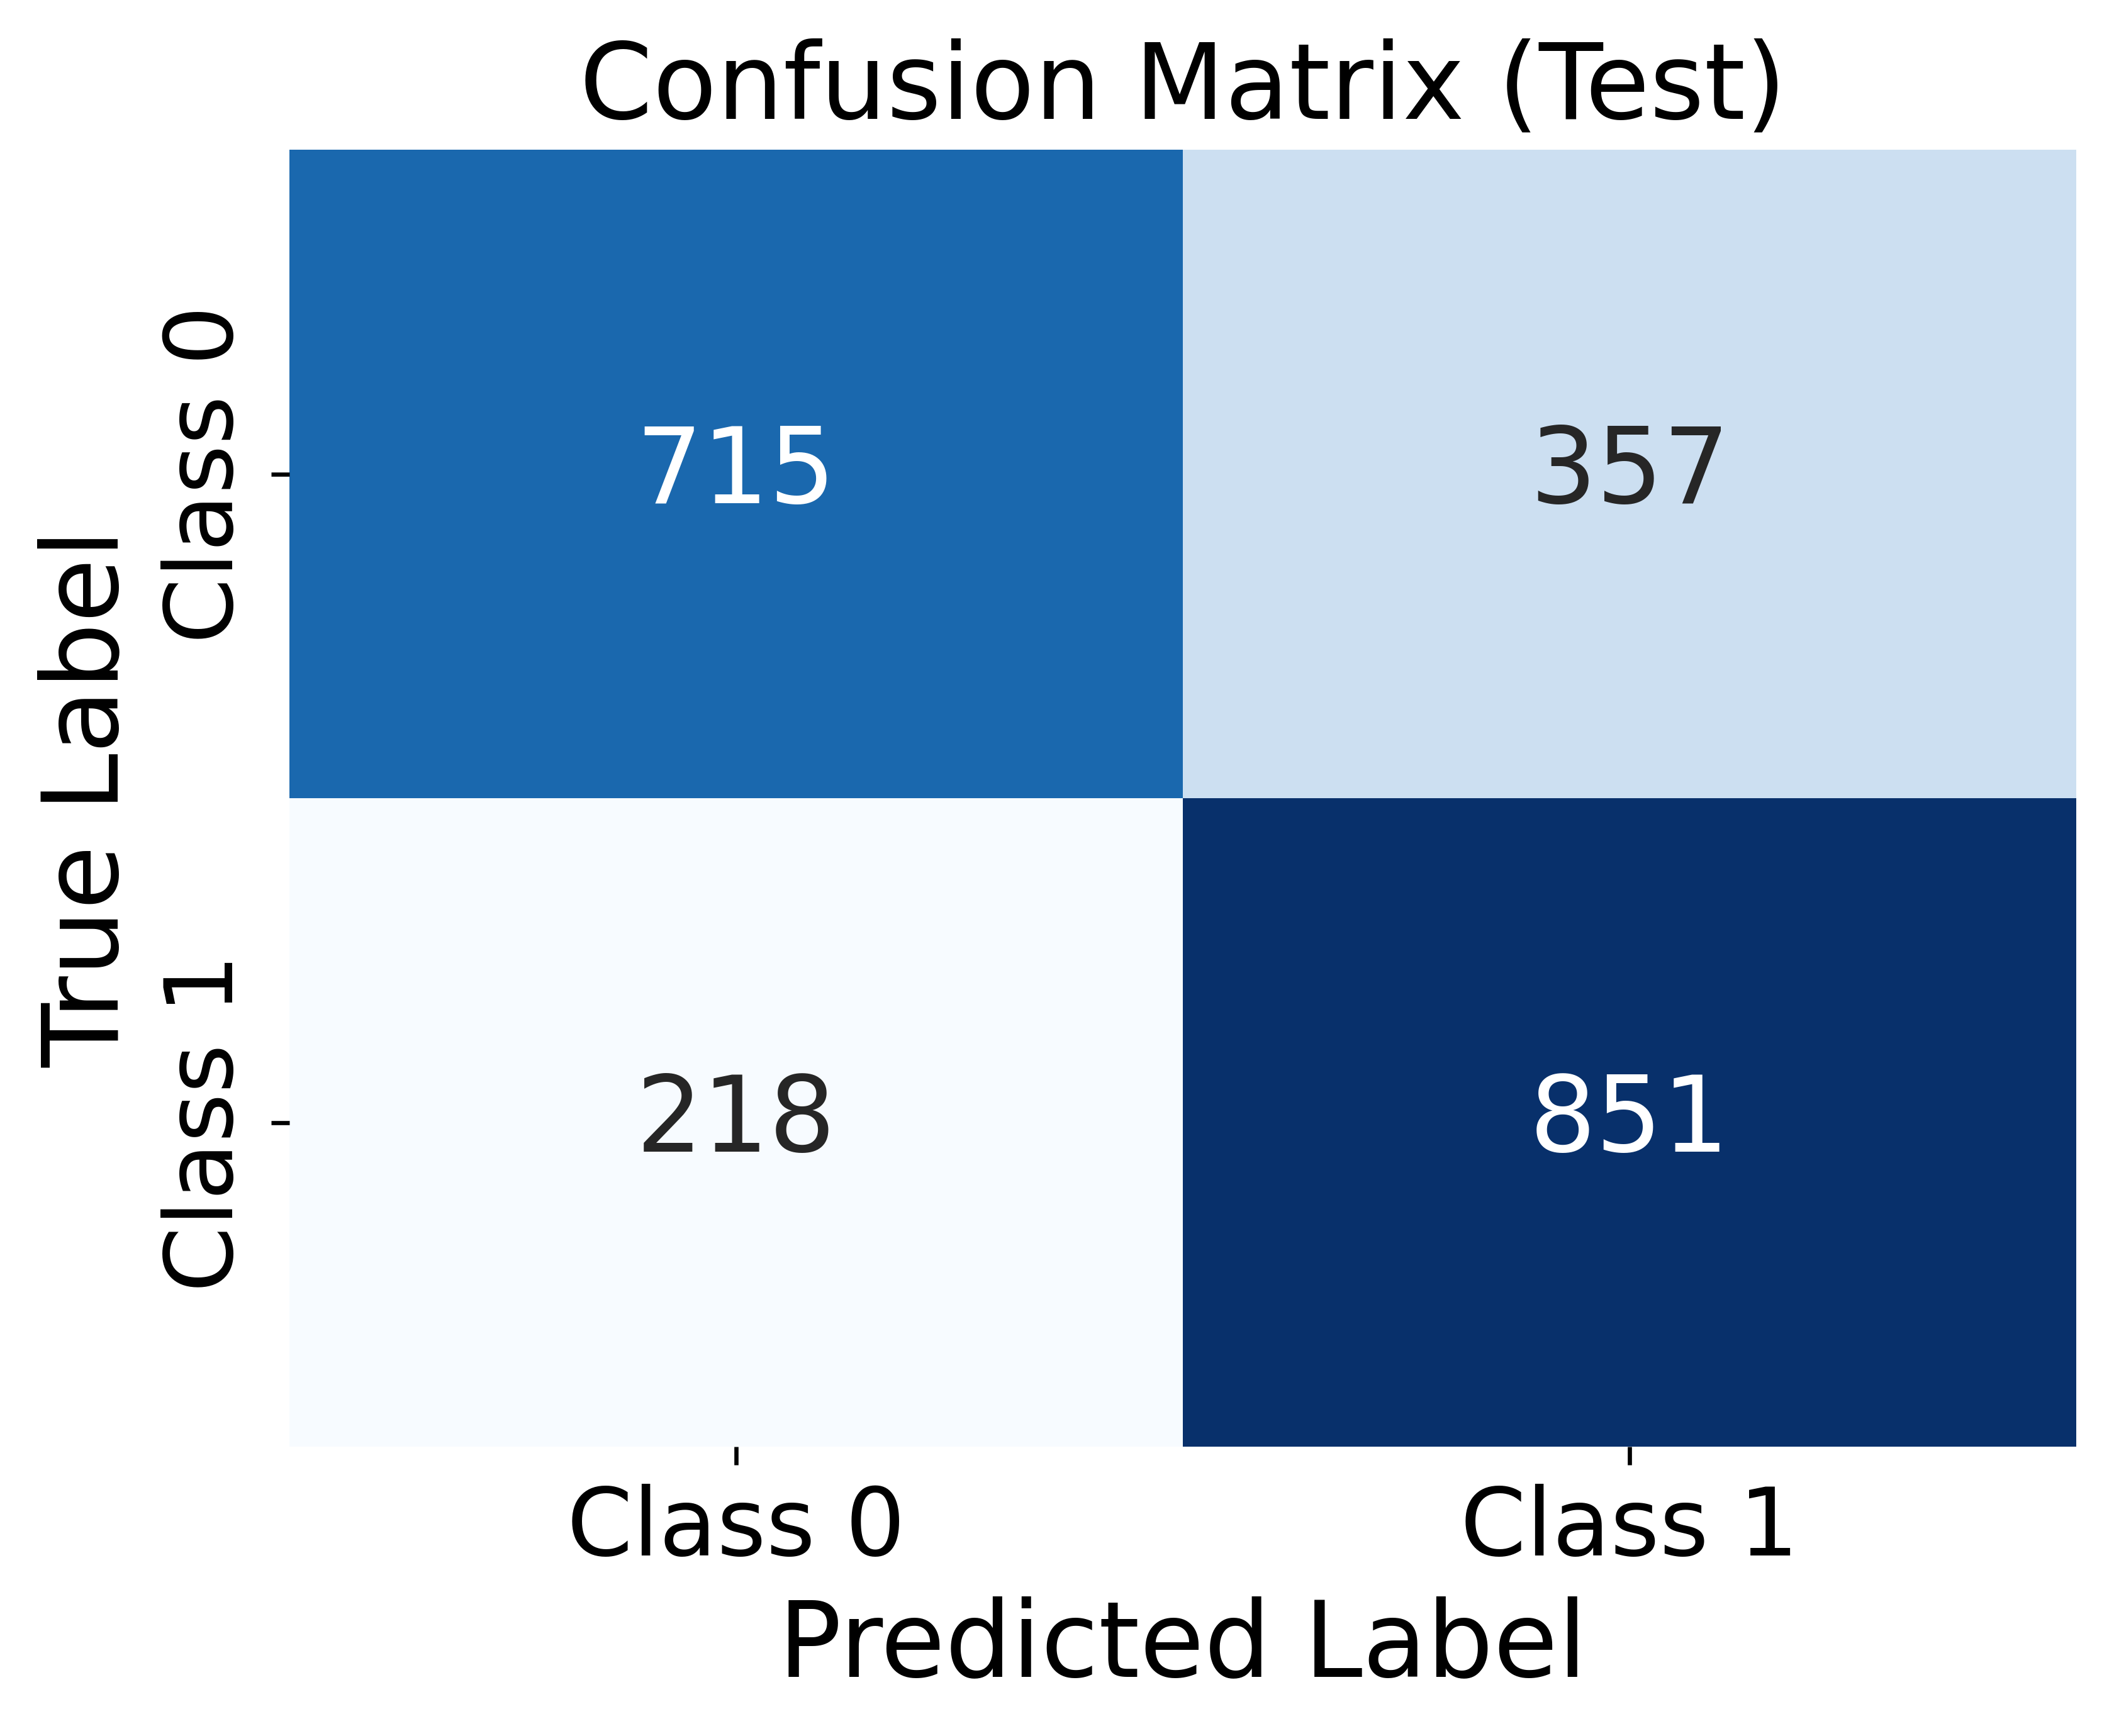

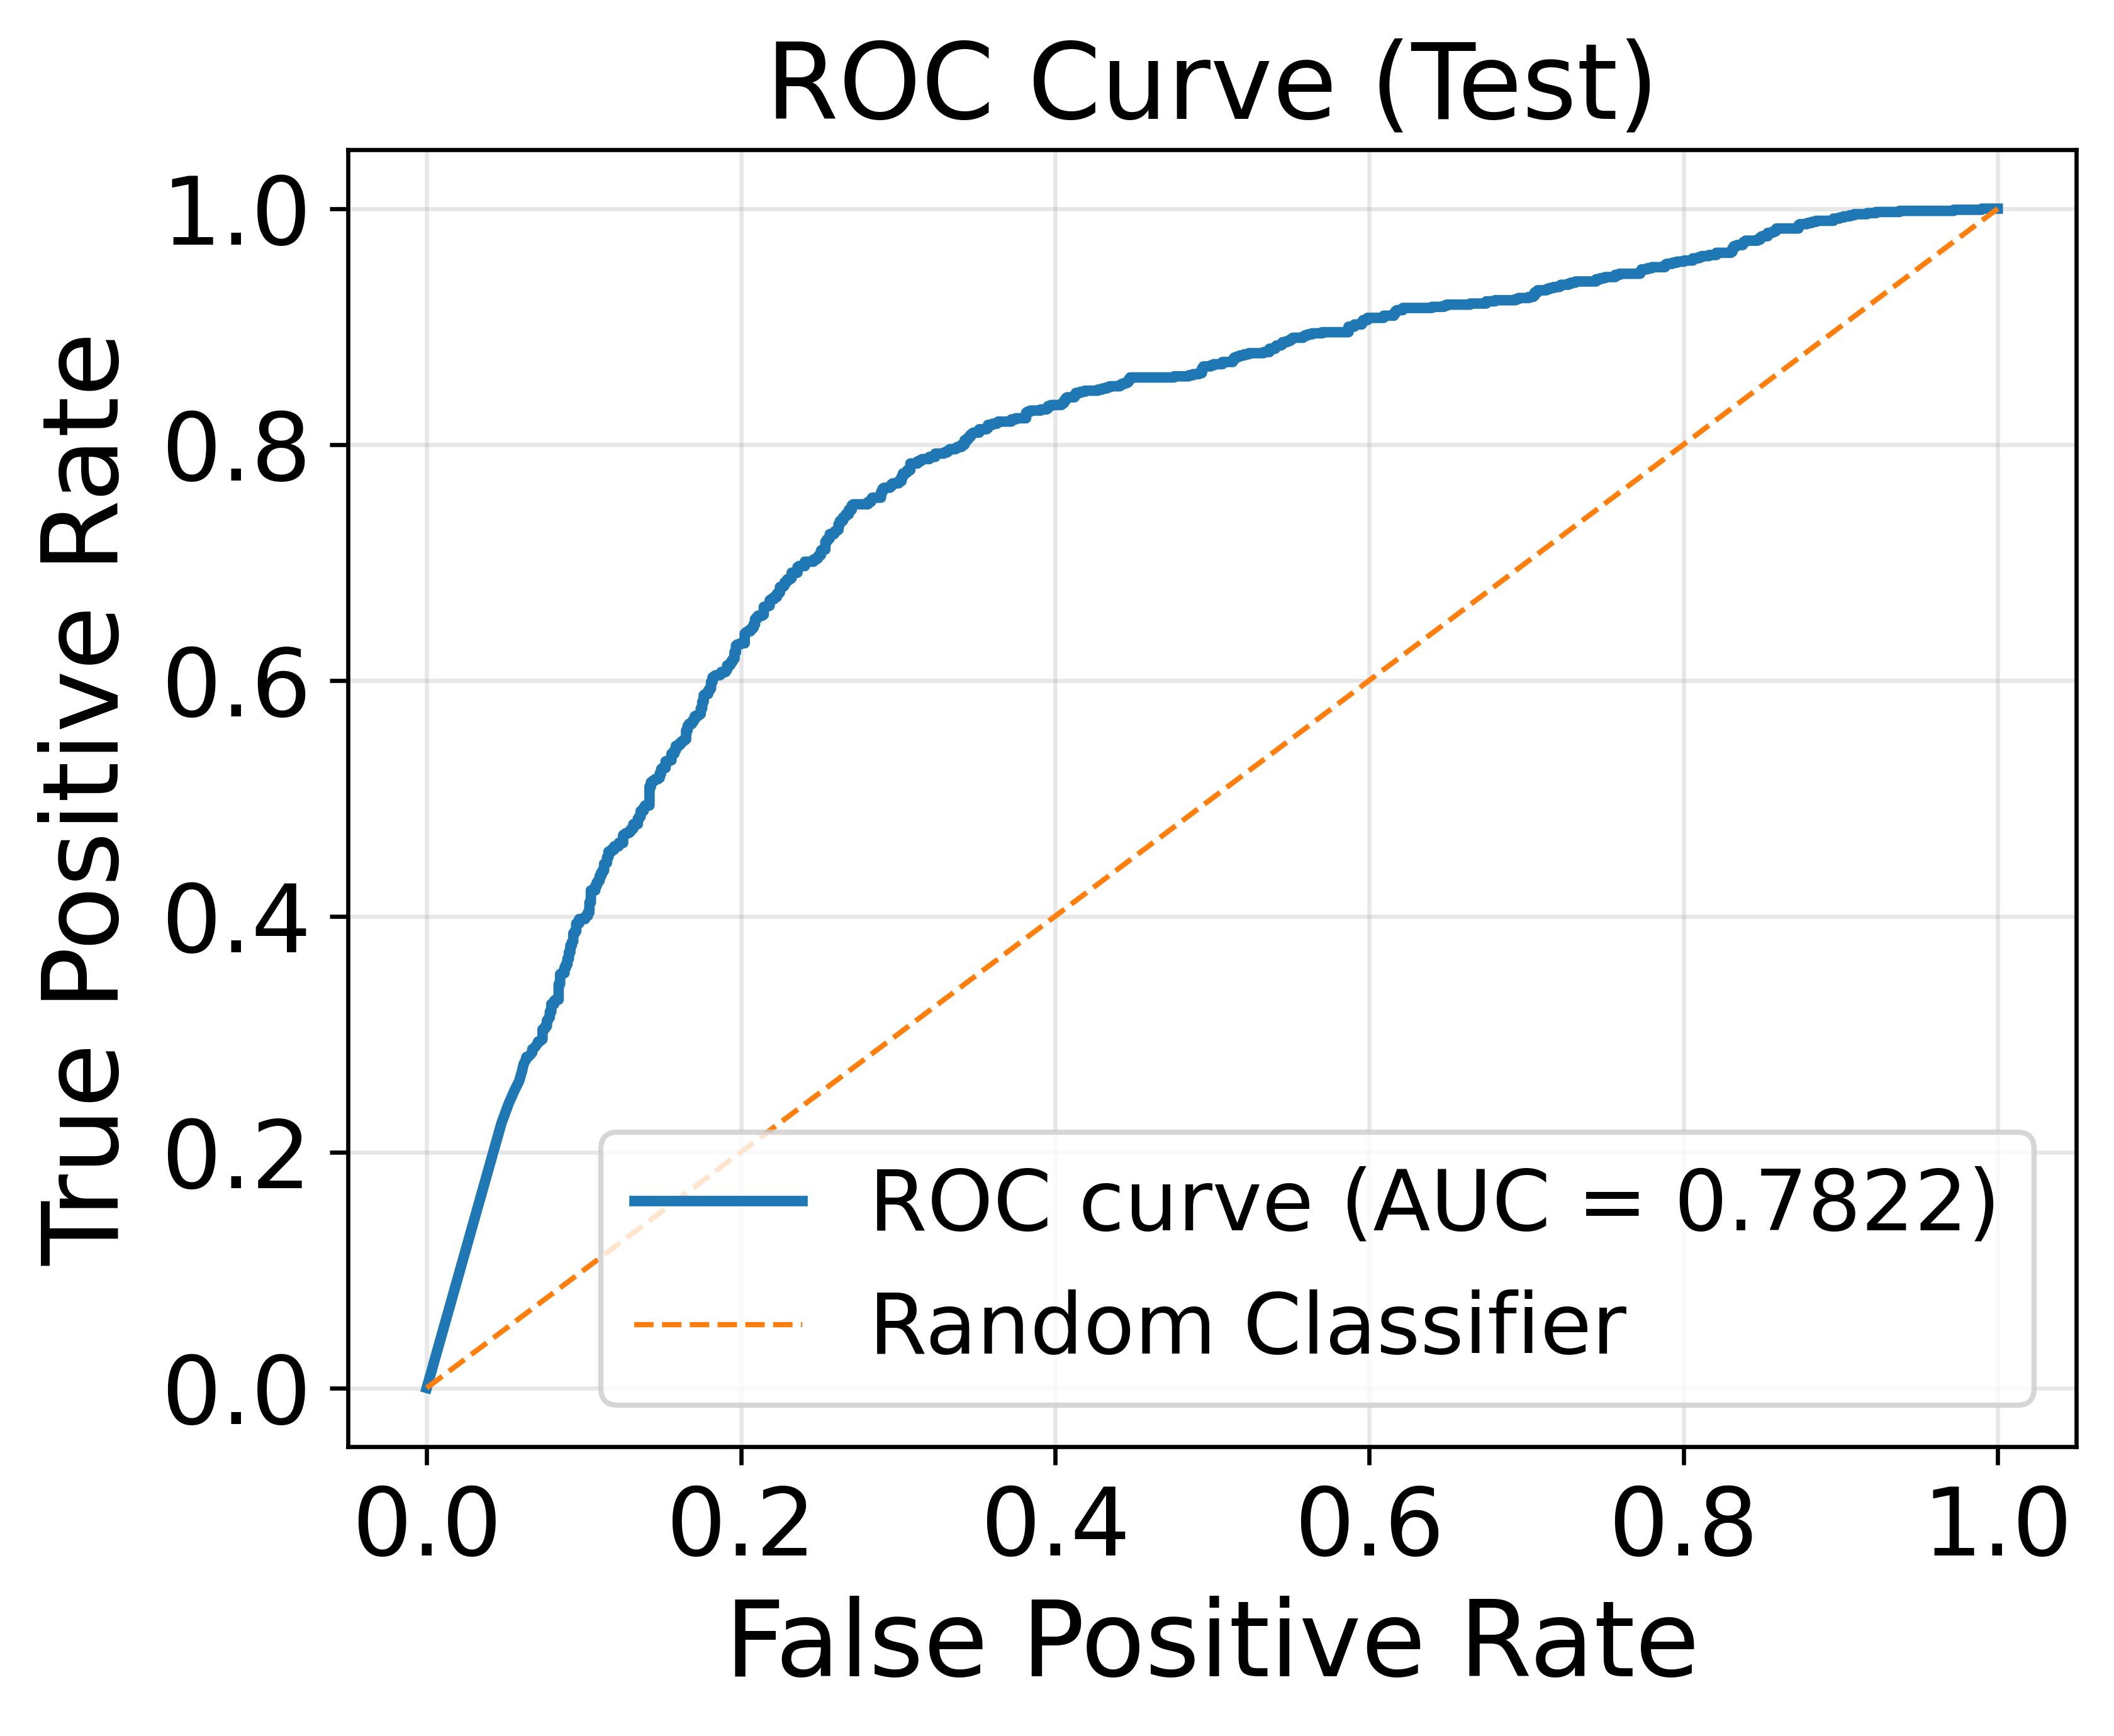

In [45]:
def evaluate_and_plot(model, X, y, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    X : np.ndarray or tensor-like
        Input feature matrix for evaluation.
    y : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y, y_pred)
    report = classification_report(y, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, X_train_pad, y_train, "Train")
val_results   = evaluate_and_plot(model, X_val_pad, y_val, "Validation")
test_results  = evaluate_and_plot(model, X_test_pad, y_test, "Test")

### Save All Results

In [46]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_Opensnoop_FLAML_Attention_Transformer/evaluation_summary.csv
Excel: Evaluation_Outputs_Opensnoop_FLAML_Attention_Transformer/evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.999900,1.000000,0.999800,0.999900,1.000000
1,Validation,0.730967,0.705246,0.792329,0.746256,0.787340
2,Test,0.731434,0.704470,0.796071,0.747475,0.782238


### Clear Final Backend Session

In [47]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()